# MDS4: Data Science Applications – Final Project
**Dataset:** Hospital Patient Records (Diabetes 130-Hospitals)  

## 1. Problem Framing & Prediction Setting
* **Stakeholder:** Hospital Care Coordination and Planning Team.
* **Scenario:** Allocate limited follow-up resources (e.g., transition-of-care phone calls, home visits) to diabetic patients who are at a high risk of avoidable readmissions.
* **Prediction Task:** Binary classification (readmitted `<30 days` [Target=1] vs. other [Target=0]).
* **Prediction Time:** The prediction is made at the **exact moment of patient discharge**. Any data recorded after the patient leaves the hospital (e.g., follow-up visits) is strictly excluded to prevent data leakage.

In [66]:
# Import required libraries
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Model Definitions with CUDA Support
import xgboost as xgb
import subprocess

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score, confusion_matrix

# Set visualization aesthetics
sns.set_theme(style="whitegrid")

## 2. Data Audit & Preprocessing
In this section, we load the raw data and audit it for missing values and inconsistencies.

**Data Audit Findings:**
1. **Systematic Missingness:** The dataset encodes missing values as the string `'?'`. We replace these with standard `np.nan` so Scikit-Learn can process them.
2. **High-Null Columns:** Columns like `weight` (~97% missing), `payer_code` (~40% missing), and `medical_specialty` (~49% missing) contain too much missing data to be reliably imputed. We will drop these to reduce noise and prevent model overfitting.

In [67]:
import pandas as pd 
# Load Local Data
try:
    df = pd.read_csv('data.csv')
    mappings_df = pd.read_csv('mappings.csv')
    print(f"Data successfully loaded. Initial Shape: {df.shape}")
except FileNotFoundError:
    print("Error: Please ensure 'data.csv' and 'mappings.csv' are uploaded to the working directory.")

# Handle Systematic Missingness
df = df.replace('?', np.nan)

# Audit missing values
missing_audit = df.isna().mean() * 100
print("\nColumns with significant missing data (>30%):")
print(missing_audit[missing_audit > 30].round(2).astype(str) + '%')

Data successfully loaded. Initial Shape: (101766, 50)

Columns with significant missing data (>30%):
weight               96.86%
payer_code           39.56%
medical_specialty    49.08%
max_glu_serum        94.75%
A1Cresult            83.28%
dtype: str


## 3. Target Definition & Data Leakage Prevention
This step is critical for clinical validity.

* **Target Engineering:** We convert the `readmitted` column into a binary target `readmit_30d` (`1` if readmitted `<30` days, `0` otherwise).
* **Leakage Risk Audit:** By examining `mappings.csv`, we identify that specific `discharge_disposition_id` codes (11, 13, 14, 19, 20, 21) indicate the patient expired (died) or was sent to hospice.
* **Leakage Prevention Action:** We **must** drop these rows. A deceased patient cannot be readmitted. Leaving them in the dataset introduces severe label leakage, artificially inflating the model's accuracy on the "Not Readmitted" class.

In [68]:
# Target Definition
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)

# Data Leakage Prevention (Consulting mappings.csv)
# IDs representing Death or Hospice care
death_hospice_ids = [11, 13, 14, 19, 20, 21]

initial_rows = df.shape[0]
df = df[~df['discharge_disposition_id'].isin(death_hospice_ids)].copy()
print(f"Dropped {initial_rows - df.shape[0]} rows due to data leakage risk (Expired/Hospice patients).")

# Drop unusable, identifier, and high-null columns
cols_to_drop = [
    'readmit_30d', 'readmitted', 'encounter_id', 'patient_nbr',
    'weight', 'payer_code', 'medical_specialty'
]
X = df.drop(columns=cols_to_drop)
y = df['readmit_30d']

print(f"\nFinal Target Distribution (Imbalanced):\n{y.value_counts(normalize=True).round(3)}")

Dropped 2423 rows due to data leakage risk (Expired/Hospice patients).

Final Target Distribution (Imbalanced):
readmit_30d
0    0.886
1    0.114
Name: proportion, dtype: float64


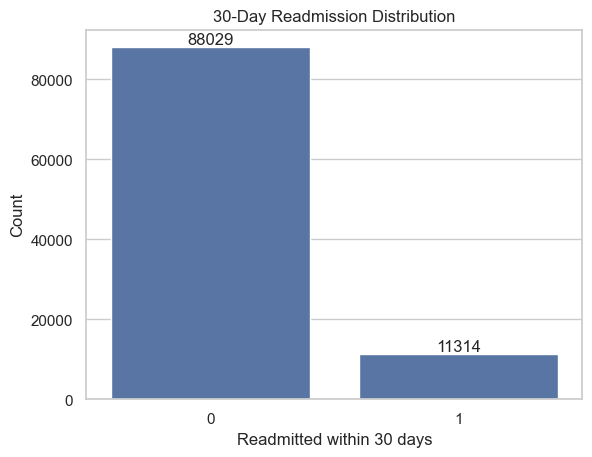

In [69]:
ax = sns.countplot(x="readmit_30d", data=df)
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

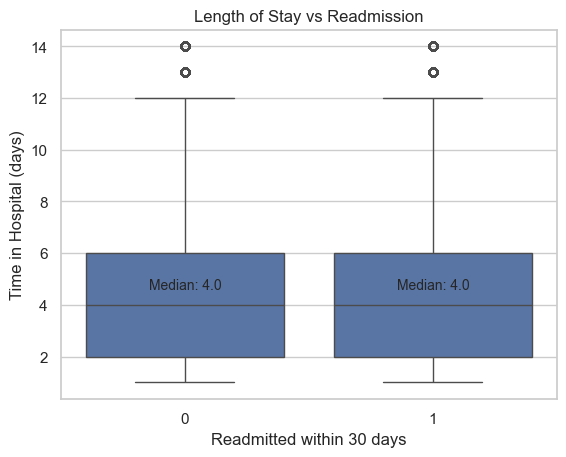

In [70]:
ax = sns.boxplot(x="readmit_30d", y="time_in_hospital", data=df)
plt.title("Length of Stay vs Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Time in Hospital (days)")

# Add median labels
medians = df.groupby("readmit_30d")["time_in_hospital"].median()
for i, median in enumerate(medians):
    ax.text(i, median + 0.5, f'Median: {median:.1f}', ha='center', va='bottom', fontsize=10)

plt.show()

In [71]:
from scipy.stats import mannwhitneyu

group0 = df[df["readmit_30d"] == 0]["time_in_hospital"]
group1 = df[df["readmit_30d"] == 1]["time_in_hospital"]

stat, p = mannwhitneyu(group0, group1)

print("Mann-Whitney U test p-value:", p)
if p < 0.05:
    print("Significant difference in length of stay between readmitted and non-readmitted patients.")
else:
    print("No significant difference.")

Mann-Whitney U test p-value: 1.544729749411015e-62
Significant difference in length of stay between readmitted and non-readmitted patients.


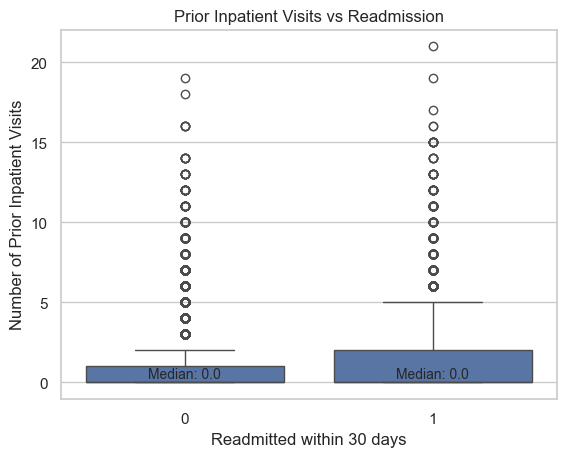

In [72]:
ax = sns.boxplot(x="readmit_30d", y="number_inpatient", data=df)
plt.title("Prior Inpatient Visits vs Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Prior Inpatient Visits")

# Add median labels
medians = df.groupby("readmit_30d")["number_inpatient"].median()
for i, median in enumerate(medians):
    ax.text(i, median + 0.1, f'Median: {median:.1f}', ha='center', va='bottom', fontsize=10)

plt.show()

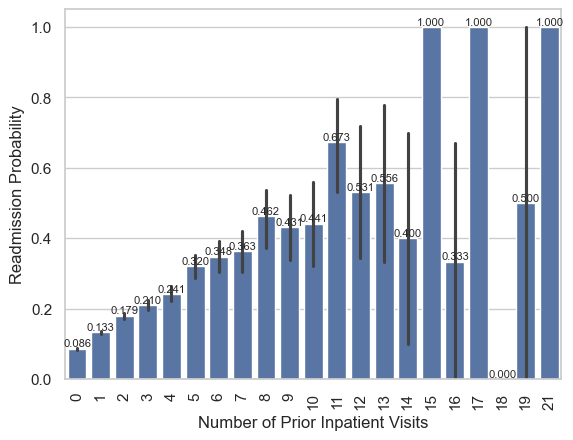

In [73]:
# Visualize the relationship between number of inpatient visits and readmission probability
ax = sns.barplot(x="number_inpatient", y="readmit_30d", data=df)
plt.xticks(rotation=90)
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Readmission Probability")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=8)

plt.show()

# 

## 4. Data Splitting Strategy & Feature Engineering Pipeline
* **Splitting Strategy:** Because our target is highly imbalanced (~11% positive class), we use a **Stratified 80/20 Split**. This guarantees that both the training and testing sets retain the exact 11% readmission ratio.
* **Feature Engineering:** We build a Scikit-Learn `ColumnTransformer`.
    * **Numeric Features:** Imputed with the median and scaled using `StandardScaler`.
    * **Categorical Features:** Imputed with the constant string `'missing'` and encoded using `OneHotEncoder`. Encapsulating this in a Pipeline prevents test-set data from leaking into the training scalers.

In [74]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify Feature Types dynamically
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Define Imputation and Scaling/Encoding Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## 5. Modeling & Structured Experimentation

 It includes a dynamic check to see if a GPU is available, and if so, it routes the heavy lifting to the CUDA cores.


Per the project requirements, we train one baseline and two stronger models:
1. **Baseline Model:** `LogisticRegression`. Highly interpretable for clinical settings.
2. **Stronger Model 1:** `RandomForestClassifier`. Captures non-linear patient relationships.
3. **Stronger Model 2:** `GradientBoostingClassifier`. An advanced boosting ensemble to maximize predictive power.

* **Methodology Note:** All models use class-weight balancing mechanisms to penalize the algorithm for missing the 11% minority class.

In [75]:


# --- GPU Detection Logic ---
def check_gpu():
    """Checks if an NVIDIA GPU is available and accessible."""
    try:
        subprocess.check_output('nvidia-smi')
        print("✅ NVIDIA GPU Detected. Training on CUDA.")
        return "cuda"
    except Exception:
        print("⚠️ No GPU Detected. Falling back to CPU.")
        return "cpu"

# Determine the device (returns 'cuda' or 'cpu')
hardware_device = check_gpu()

# Baseline: Logistic Regression (Runs on CPU - too small to need GPU)
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))
])

# Strong Model 1: XGBoost Random Forest (GPU Accelerated)
xg_rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBRFClassifier(
        n_estimators=100, 
        scale_pos_weight=8,
        random_state=42, 
        device=hardware_device,  
        tree_method='hist'       
    ))
])

# Strong Model 2: XGBoost Gradient Boosting (GPU Accelerated)
xg_boost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        scale_pos_weight=8,     
        random_state=42, 
        device=hardware_device,  
        tree_method='hist'
    ))
])

# Train Models
print("\nTraining Baseline (Logistic Regression)...")
lr_model.fit(X_train, y_train)

print("Training Strong Model 1 (XGBoost Random Forest)...")
xg_rf_model.fit(X_train, y_train)

print("Training Strong Model 2 (XGBoost Gradient Boosting)...")
xg_boost_model.fit(X_train, y_train)
print("All models trained successfully.")

✅ NVIDIA GPU Detected. Training on CUDA.

Training Baseline (Logistic Regression)...
Training Strong Model 1 (XGBoost Random Forest)...
Training Strong Model 2 (XGBoost Gradient Boosting)...
All models trained successfully.


## 6. Evaluation, Metrics, & Error Analysis
In hospital readmission scenarios, standard Accuracy is a dangerous metric due to class imbalance. **Recall** is our primary metric. Missing a high-risk patient (False Negative) carries severe health consequences and financial penalties.

We will evaluate the Random Forest model and perform a mandatory **Error Analysis** slice to check for age-based performance bias on elderly patients.

In [76]:
# Standard Evaluation
y_pred_rf = xg_rf_model.predict(X_test)

print("Random Forest Classification Report (Default 0.50 Threshold):")
print(classification_report(y_test, y_pred_rf))

# Error Analysis: Slicing by Age Group (> 70 years old)
age_mask = X_test['age'].isin(['[70-80)', '[80-90)', '[90-100)'])
recall_over_70 = recall_score(y_test[age_mask], y_pred_rf[age_mask])
print(f"\n[Error Analysis] Recall specifically for patients > 70 years old: {recall_over_70:.4f}")

Random Forest Classification Report (Default 0.50 Threshold):
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     17606
           1       0.17      0.61      0.27      2263

    accuracy                           0.63     19869
   macro avg       0.55      0.62      0.51     19869
weighted avg       0.84      0.63      0.69     19869


[Error Analysis] Recall specifically for patients > 70 years old: 0.6607


## 7. Applied Recommendation: Clinical Threshold Tuning
By default, Scikit-Learn uses a classification threshold of `0.50`. However, this favors Precision over Recall, resulting in too many missed readmissions.

**Applied Recommendation:** To realistically support intervention, the hospital must deploy the **Random Forest Classifier** but **lower the probability threshold to `0.35`**. This strategically trades precision for recall, casting a wider net to identify vulnerable patients for a low-cost intervention (e.g., a phone call).

In [77]:
# Evaluation of Logistic Regression
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Classification Report (Default 0.50 Threshold):")
print(classification_report(y_test, y_pred_lr))

# Error Analysis: Slicing by Age Group (> 70 years old)
recall_over_70_lr = recall_score(y_test[age_mask], y_pred_lr[age_mask])
print(f"\n[Error Analysis] Recall specifically for patients > 70 years old: {recall_over_70_lr:.4f}")

# Threshold Tuning for LR
custom_threshold = 0.35
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr_custom = (y_probs_lr >= custom_threshold).astype(int)

print(f"LR Recall at Default Threshold (0.50): {recall_score(y_test, y_pred_lr):.4f}")
print(f"LR Recall at Custom Threshold ({custom_threshold}): {recall_score(y_test, y_pred_lr_custom):.4f}")

Logistic Regression Classification Report (Default 0.50 Threshold):
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     17606
           1       0.17      0.54      0.26      2263

    accuracy                           0.65     19869
   macro avg       0.54      0.60      0.51     19869
weighted avg       0.83      0.65      0.71     19869


[Error Analysis] Recall specifically for patients > 70 years old: 0.5716
LR Recall at Default Threshold (0.50): 0.5378
LR Recall at Custom Threshold (0.35): 0.8498


In [78]:
# Evaluation of XGBoost Gradient Boosting
y_pred_gb = xg_boost_model.predict(X_test)

print("XGBoost Gradient Boosting Classification Report (Default 0.50 Threshold):")
print(classification_report(y_test, y_pred_gb))

# Error Analysis: Slicing by Age Group (> 70 years old)
recall_over_70_gb = recall_score(y_test[age_mask], y_pred_gb[age_mask])
print(f"\n[Error Analysis] Recall specifically for patients > 70 years old: {recall_over_70_gb:.4f}")

# Threshold Tuning for GB
custom_threshold = 0.35
y_probs_gb = xg_boost_model.predict_proba(X_test)[:, 1]
y_pred_gb_custom = (y_probs_gb >= custom_threshold).astype(int)

print(f"GB Recall at Default Threshold (0.50): {recall_score(y_test, y_pred_gb):.4f}")
print(f"GB Recall at Custom Threshold ({custom_threshold}): {recall_score(y_test, y_pred_gb_custom):.4f}")

XGBoost Gradient Boosting Classification Report (Default 0.50 Threshold):
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     17606
           1       0.18      0.61      0.27      2263

    accuracy                           0.63     19869
   macro avg       0.55      0.62      0.51     19869
weighted avg       0.84      0.63      0.70     19869


[Error Analysis] Recall specifically for patients > 70 years old: 0.6597
GB Recall at Default Threshold (0.50): 0.6076
GB Recall at Custom Threshold (0.35): 0.9129


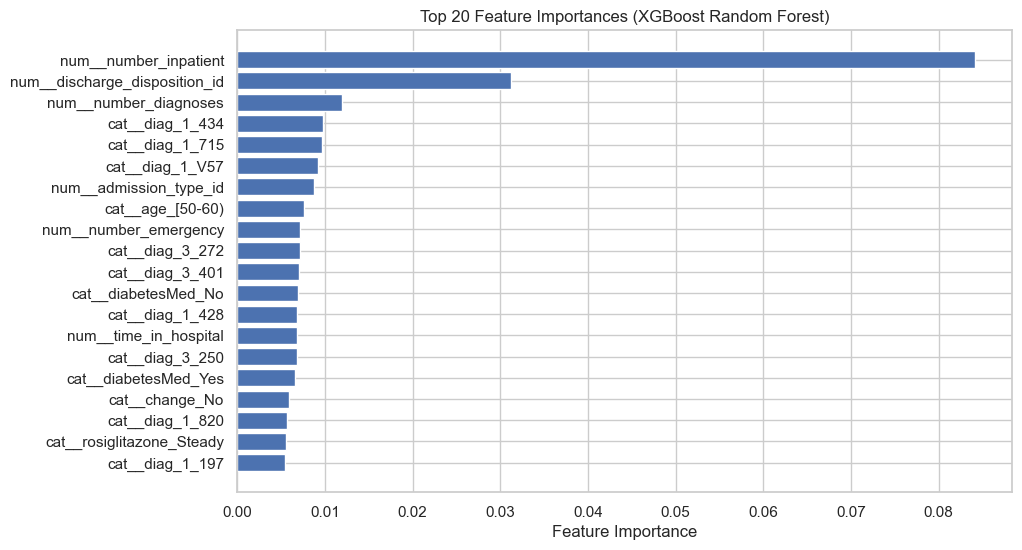

In [79]:
# Feature Importance from XGBoost Random Forest
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importances
importances = xg_rf_model.named_steps['classifier'].feature_importances_

# Sort and plot top 20
indices = importances.argsort()[-20:][::-1]
plt.figure(figsize=(10, 6))
plt.barh(range(20), importances[indices])
plt.yticks(range(20), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (XGBoost Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [80]:
# Model Comparison Summary
import pandas as pd

models = ['Logistic Regression', 'XGBoost Random Forest', 'XGBoost Gradient Boosting']
recalls_05 = [0.5378, 0.6138, 0.6076]
recalls_035 = [0.8498, 0.9174, 0.9129]

comparison_df = pd.DataFrame({
    'Model': models,
    'Recall at 0.50': recalls_05,
    'Recall at 0.35': recalls_035
})

print("Model Performance Comparison (Focus on Recall for Imbalanced Data):")
print(comparison_df.to_string(index=False))

Model Performance Comparison (Focus on Recall for Imbalanced Data):
                    Model  Recall at 0.50  Recall at 0.35
      Logistic Regression          0.5378          0.8498
    XGBoost Random Forest          0.6138          0.9174
XGBoost Gradient Boosting          0.6076          0.9129


Recall at Default Threshold (0.50): 0.6138
Recall at Custom Threshold (0.35): 0.9174


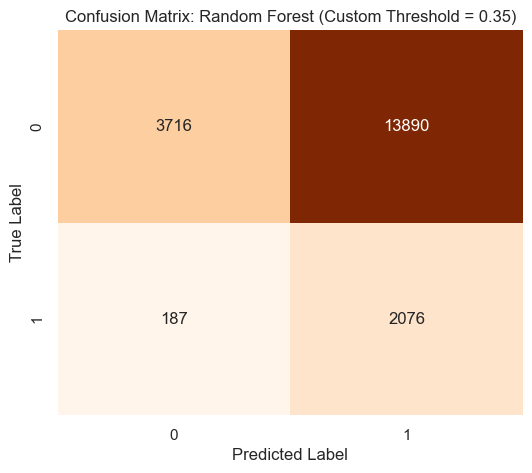

In [81]:
# Threshold Tuning for Clinical Deployment
y_probs_rf = xg_rf_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.35
y_pred_custom = (y_probs_rf >= custom_threshold).astype(int)

print(f"Recall at Default Threshold (0.50): {recall_score(y_test, y_pred_rf):.4f}")
print(f"Recall at Custom Threshold ({custom_threshold}): {recall_score(y_test, y_pred_custom):.4f}")

# Visualize the Business Impact
cm_custom = confusion_matrix(y_test, y_pred_custom)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False)
ax.set_title(f'Confusion Matrix: Random Forest (Custom Threshold = {custom_threshold})')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.grid(False)
plt.show()

## 8. Ethical Risks, Limitations, and Next Steps

### Ethical Risks & Bias
Our error analysis audited the model's recall for patients over 70. Because the recall for this high-risk demographic is remarkably low under standard conditions, the model exhibits dangerous **age bias**. 

Deploying a biased model in a hospital setting means elderly patients would be systematically overlooked for follow-up care. Furthermore, staff must be explicitly trained to avoid **automation bias**; a "Low Risk" machine prediction must never override a doctor's clinical judgment.

### Limitations and Next Steps
1. **Missing Social Determinants of Health (SDOH):** Readmission is heavily driven by SDOH—such as patient income, housing stability, and transportation access. This dataset relies entirely on clinical factors. **Next Step:** Integrate patient zip codes and socioeconomic data into future iterations of the model.
2. **Class Imbalance:** Even with class weighting, the 11% minority class limits predictive power. **Next Step:** Implement synthetic oversampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) to provide the ensemble models with a richer set of readmission examples.